## Neural Network with Backpropagation
- [Cost Function](#Cost-Function)
- [Gradient Computation](#Gradient-Computation)
- [Backpropagation Algorithm](#Backpropagation-Algorithm)
- [Backpropagation Intuition](#Backpropagation-Intuition)
--- 

### Cost Function
* $L$ : total number of layers in the network
* $S_{l}$ : number of unit(not counting bias) in the layer $l$
* $K$ : number of output units/classes  

$$ h_{\theta}(x) \in \mathbb{R}^{K}, ((h_{\theta}(x))_{i} = i^{th} output $$   
$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K}[y^{(i)}_{k} \cdot \log{((h_{\theta}{(x^{(i)})})_{k})} + (1-y^{(i)}_{k})log{((1-h_{\theta}{(x^{(i)})})_{k})}] + \frac{\lambda}{2m}\sum_{l=1}^{L}\sum_{i=1}^{S_{l}}\sum_{j=1}^{S_{l}+1}(\theta^{(l)}_{j,i})^{2}$$

### Gradient Computation
Minimizing our cost function $ \begin{array}{ccc}
min \\ \theta
\end{array} J({\theta})$  
Need code to compute:
$$J(\theta)$$  
$$\displaystyle \frac{\partial}{\partial\theta^{(l)}_{i,j}}J(\theta)$$  
$$\delta^{(l)} = ((\Theta^{(l)})^T \delta^{(l+1)})\ .*\ g^{\prime}(z^{(l)}),\ \ \ g^{\prime}(z^{(l)}) = a^{(l)}\ .*\ (1 - a^{(l)})$$  

$\frac{\partial}{\partial\theta^{(2)}_{i,j}}J(\theta)$  
$= \sum_{k}^{n}\left[ \frac{\partial J(\theta) }{\partial a^{(4)}_{k}} \cdot \frac{\partial a^{(4)}_{k}}{\partial\theta^{(2)}_{i,j}} \right]  
 = \sum_{k}^{n}\left[\frac{\partial J(\theta) }{\partial a^{(4)}_{k}} \cdot \frac{\partial a^{(4)}_{k}}{a^{(3)}_{i}} \cdot \frac{\partial a^{(3)}_{i}}{\partial\theta^{(2)}_{i,j}} \right]
= \sum_{k}^{n}\left[ \frac{\partial J(\theta) }{\partial a^{(4)}_{k}} \cdot \frac{\partial g(z^{(4)}_{k})}{\partial a^{(3)}_{i}} \cdot \frac{\partial g(z^{(3)}_{i})}{\partial\theta^{(2)}_{i,j}} \right] $  
$ = \sum_{k}^{n}\left[ \frac{\partial J(\theta) }{\partial a^{(4)}_{k}} \cdot g^{\prime}(z^{(4)}_{k}) \cdot  \frac{\partial z^{(4)}_{k}}{\partial a^{(3)}_{i}} \cdot g^{\prime}(z^{(3)}_{i}) \cdot \frac{\partial z^{(3)}_{i}}{\partial\theta^{(2)}_{i,j}} \right]$  
$ = \sum_{k}^{n}\left[ (a^{(4)}_{k} - y_{k}) \cdot g^{\prime}(z^{(4)}_{k}) \cdot  \theta^{(3)}_{k \ i} \cdot g^{\prime}(z^{(3)}_{i}) \cdot a^{(2)}_{j} \right]$  
$ = \sum_{k}^{n}\left[ (a^{(4)}_{k} - y_{k}) \cdot g^{\prime}(z^{(4)}_{k}) \cdot  \theta^{(3)}_{k \ i} \right] \cdot g^{\prime}(z^{(3)}_{j}) \cdot a^{(2)}_{j} $  
$ = \sum_{k}^{n}\left[ \delta^{4}_{k} \cdot  \theta^{(3)}_{k \ j} \right] \cdot g^{\prime}(z^{(3)}_{i}) \cdot a^{(2)}_{j} $  
$ = \delta^{3}_{i} \cdot a^{(2)}_{j} $


### Backpropagation Algorithm
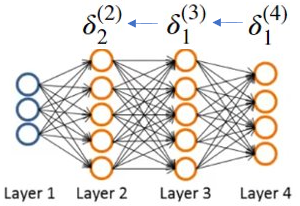

Traning set ${(x^{(1)}, y^{(1)}), \dots, (x^{(m)}, y^{(m)})}$  
Set $\Delta^{(l)}_{i,j} = 0$ (for all $l,i,j$)  
For training example $i$ =1 to m
1. Compute $\delta^{(L)} = a^{(L)} - y^{(t)}$, $\delta^{(l)}_{j}$ error of node $j$ in layer $l$  
$$\delta^{(4)}_{j} = a^{(4)}_{j} - y_{j},\ (h_{\theta}(x))_{j}=g(z^{(4)}_{j}))$$
2. Compute $\delta^{(L-1)}, \delta^{(L-1)}, \dots , \delta^{(2)}$  
 $$\delta^{(3)}_{j} = \left( \theta^{(3)} \right)^{T} \delta^{(4)}_{j} .* g^{\prime}(z^{(3)}) $$
 $$\delta^{(2)}_{j} = \left( \theta^{(2)} \right)^{T} \delta^{(3)}_{j} .* g^{\prime}(z^{(2)}) $$  
3. $\frac{\partial}{\partial\theta^{(l)}_{i,j}}J(\theta) = a^{(l)}_{j}\delta^{(l+1)}_{i} $  
$$\Delta^{(l)}_{i,j} = \Delta^{(l)}_{i,j} + a^{(l)}_{j}\delta^{(l+1)}_{i}$$  

Finally:  
* $if\ j \ne 0,\  D^{(l)}_{i,j} = \frac{1}{m}\Delta^{(l)}_{i,j} + \lambda\theta^{(l)}_{i,j} $  
* $if\ j = 0,\  D^{(l)}_{i,j} = \frac{1}{m}\Delta^{(l)}_{i,j} $  




### Backpropagation Intuition
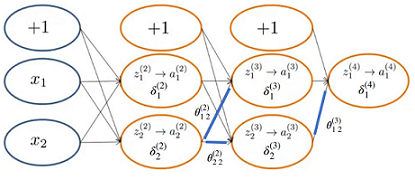

Suppose imple non-multiclass classification (k = 1) and ignoring regularization($\lambda = 0$), the cost is computed with:  

$cost(i) = y^{((i)}log(h\theta(x^{(i)})) + (1-y^{(i)})log(1-h\theta(x^{(i)}))$  
$cost(i) \approx (h\theta(x^{(i)}) - y^{(i)})^{2}$  

$\delta^{(l)}_{j}$ is the **error** for $a^{(l)}_j$ (unit j in layer l). More formally, the delta values are actually the derivative of the cost function:  
$$\displaystyle \delta^{(l)}_{j} = \frac{\partial}{\partial z^{(l)}_{j}}cost(i)$$  
$$\displaystyle z^{(l)}_{j} = \theta^{(l-1)}_{j} a^{(l-1)}_{j}$$  

error of Neural Network of weight  
$\delta^{(4)}_{1} = a^{(4)}_{1} - y_{1}$  
$\delta^{(3)}_{2} = \theta^{(3)}_{1\ 2} \cdot \delta^{(4)}_{1}$  
$\delta^{(2)}_{2} = \theta^{(2)}_{1\ 2} \cdot \delta^{(3)}_{1} + \theta^{(2)}_{2\ 2} \cdot \delta^{(3)}_{2}$  
